# Molecular Solubility Prediction

 *Raya JannatAbadi* <br/>

---

## Introduction

One of the most important challenges in drug development is predicting whether a candidate molecule will be absorbed by the body. A key property governing this is **aqueous solubility** — how well a molecule dissolves in water.

In this assignment, you will build a machine learning pipeline to predict aqueous solubility (measured as **LogS**, the log₁₀ of solubility in mol/L) from molecular structure alone. This is the kind of model that pharmaceutical companies use to screen millions of virtual compounds before any lab experiment is run.

You will use:
- **RDKit** — the standard open-source cheminformatics toolkit
- **ESOL dataset** — 1,128 drug-like molecules with measured solubility (Delaney, 2004)
- **Random Forest** — a powerful ensemble machine learning model

Work through each section in order. Read every explanation carefully before writing code. Answer all discussion questions in the space provided.

---

## Solubility Scale Reference

| LogS Range | Interpretation |
|---|---|
| LogS > −2 | Highly soluble — excellent |
| −4 < LogS < −2 | Moderately soluble — acceptable |
| LogS < −4 | Poorly soluble — problematic for drugs |

--- 

## Part 0 — Import Libraries

In [2]:
#!pip install rdkit
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, AllChem, Lipinski

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
np.random.seed(42)

print("All libraries imported successfully.")

All libraries imported successfully.


## Part 1 — Load the ESOL Dataset

The ESOL dataset is stored in a CSV file called `delaney-processed.csv`.  
It has a `smiles` column (molecular structure) and a column with the measured solubility.

### Task 1.1 — Load and inspect the data

In [3]:
url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"

# TODO: Load the CSV into a DataFrame named `df` using pd.read_csv()
df = pd.read_csv("./delaney-processed.csv")

# TODO: Print the shape of the dataset (number of rows and columns)
print(f"Dataset shape:", df.shape)

# TODO: Print the column names
print("Column names:",list(df.columns))

# TODO: Show the first 5 rows
df.head()

Dataset shape: (1128, 10)
Column names: ['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles']


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


### Task 1.2 — Simplify the DataFrame and Plot the solubility distribution

Working dataset: 1128
Solubility range: -11.60 to 1.58


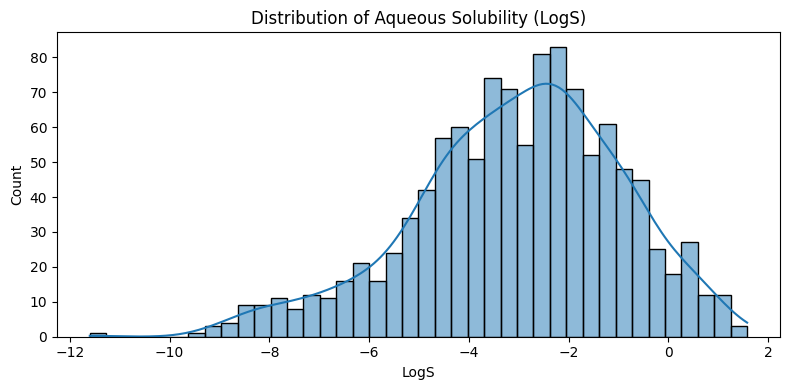

In [5]:
# TODO: Keep only 'smiles' and the solubility column (check the column name carefully!)
# Rename the solubility column to 'logS' for convenience
df = df[['smiles', 'measured log solubility in mols per litre']].copy()
df.columns = ['smiles', 'logS']

print(f"Working dataset: {df.shape[0]}")
print(f"Solubility range: {df['logS'].min():.2f} to {df['logS'].max():.2f}")


# TODO: Create a histogram of the LogS values using seaborn (sns.histplot)
# - Set bins=40
# - Add a KDE curve (kde=True)
# - Add axis labels and a title

plt.figure(figsize=(8, 4))

# Your plotting code here:
sns.histplot(df['logS'], bins=40, kde=True)
plt.xlabel("LogS")
plt.ylabel("Count")
plt.title("Distribution of Aqueous Solubility (LogS)")

plt.tight_layout()
plt.show()


**Question 1.3:** Based on the histogram, what is the approximate median LogS? Is this dataset biased toward soluble or insoluble compounds?

> **Your answer:**
> The approximate median LogS is around -3.
> Most compounds are concentrated between -4 and -2, which corresponds to the moderately soluble range. There are also many compounds with LogS values below -4, while fewer compounds are highly soluble above -2. Therefore, the dataset is somewhat biased toward moderately soluble and poorly soluble compounds rather than highly soluble compounds.

---

## Part 2 — Visualize Molecular Structures

SMILES (Simplified Molecular-Input Line-Entry System) strings encode molecular structure as text.  
For example, `CCO` is ethanol and `c1ccccc1` is benzene.

RDKit converts SMILES into molecular objects that can be drawn and analyzed.

### Task 2.1 — Parse SMILES and draw molecules

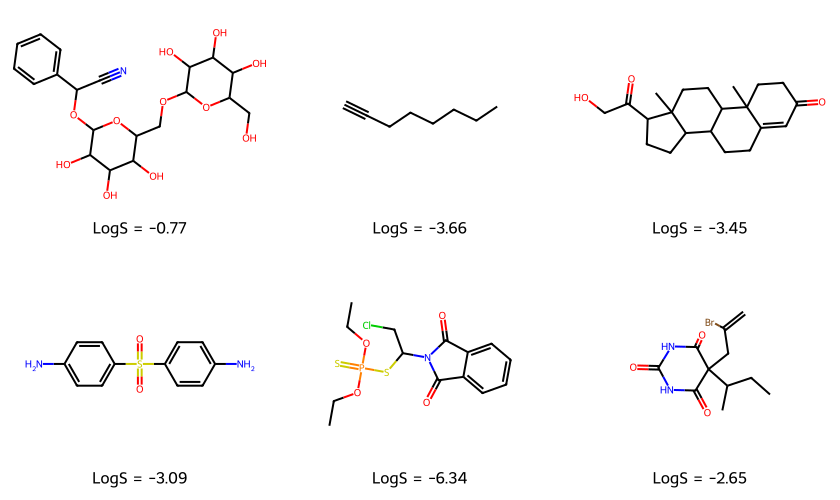

In [6]:
# We select 6 molecules with different solubility values to compare
sample_idx = [0, 50, 100, 200, 500, 900]
sample_smiles = df['smiles'].iloc[sample_idx].tolist()
sample_logS   = df['logS'].iloc[sample_idx].tolist()

# TODO: Convert each SMILES string to an RDKit molecule object using Chem.MolFromSmiles()
# Store the result in a list called `molecules`
molecules = [Chem.MolFromSmiles(smi) for smi in sample_smiles]

# TODO: Create a legend for each molecule showing its LogS value (e.g., "LogS = -2.34")
legends = [f"LogS = {ls:.2f}" for ls in sample_logS]

# TODO: Use Draw.MolsToGridImage() to display all 6 molecules in a 3-column grid
# Hint: use molsPerRow=3, subImgSize=(280, 250), and the legends you created above
img = Draw.MolsToGridImage(
    molecules,
    molsPerRow=3,
    subImgSize=(280, 250),
    legends=legends
)
img

**Question 2.1:** Look at the drawn molecules. Can you identify any visual pattern between molecular structure and solubility? (Think about size, polarity, rings, and functional groups.)

> **Your answer:**
   - (1): many OH groups → high polarity → better water solubility → higher LogS 
   - (2): hydrocarbon chain → nonpolar structure → lower solubility
   - (3):fused rings + large hydrophobic core + few polar groups → moderate/low solubility → moderate/low LogS
   - (4):large and hydrophobic structure → very low solubility → very low LogS
   - (5):large hydrophobic structure + aromatic ring + halogen-containing groups → very low solubility → very low LogS
   - (6):polar NH and carbonyl groups + some hydrophobic parts → moderate solubility → moderate LogS
> so we can say: More polar groups and hydrogen-bonding groups increase solubility, while larger molecular size, hydrophobic rings, halogens, and long carbon chains decrease solubility. This pattern is visible in the examples: the molecule with many OH groups has the highest LogS, while the larger hydrophobic molecule has the lowest LogS.

---

## Part 3 — Molecular Descriptor Engineering

Molecular descriptors are numbers that summarize key physicochemical properties of a molecule.  
We will compute the following 7 descriptors, which are also part of **Lipinski's Rule of Five**:

| Descriptor | Function to Call | What it Measures |
|---|---|---|
| Molecular Weight | `Descriptors.MolWt(mol)` | Mass of the molecule |
| LogP | `Descriptors.MolLogP(mol)` | Lipophilicity (fat vs. water preference) |
| TPSA | `Descriptors.TPSA(mol)` | Topological polar surface area |
| Rotatable Bonds | `Lipinski.NumRotatableBonds(mol)` | Molecular flexibility |
| H-Bond Donors | `Lipinski.NumHDonors(mol)` | Number of N-H and O-H groups |
| H-Bond Acceptors | `Lipinski.NumHAcceptors(mol)` | Number of N and O atoms |
| Ring Count | `Lipinski.RingCount(mol)` | Number of rings |

### Task 3.1 — Write the descriptor calculation function

In [7]:
def calculate_descriptors(smiles: str):
    """
    Calculate physicochemical descriptors for a molecule.

    Parameters
    ----------
    smiles : str
        SMILES string of the molecule.

    Returns
    -------
    dict of {descriptor_name: value}, or None if SMILES is invalid.
    """
    # TODO: Convert the SMILES to a molecule object
    mol = Chem.MolFromSmiles(smiles)

    # TODO: If the molecule is invalid (None), return None
    if mol is None:
        return None

    # TODO: Compute and return all 7 descriptors as a dictionary
    return {
        "MolWt":          Descriptors.MolWt(mol),
        "LogP":           Descriptors.MolLogP(mol),
        "TPSA":           Descriptors.TPSA(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "HDonors":        Lipinski.NumHDonors(mol),
        "HAcceptors":     Lipinski.NumHAcceptors(mol),
        "RingCount":      Lipinski.RingCount(mol),
    }

### Task 3.2 — Apply the function to all molecules

In [8]:
# TODO: Apply calculate_descriptors to every SMILES in df['smiles']
# Store results in a list, then convert to a DataFrame named `descriptor_df`
descriptor_list = [calculate_descriptors(smi) for smi in df['smiles']]
descriptor_df   = pd.DataFrame(descriptor_list)

# TODO: How many molecules returned None (invalid SMILES)?
n_failed = sum(x is None for x in descriptor_list)
print(f"Invalid SMILES: {n_failed}")

# TODO: Remove rows with any missing values
descriptor_df = descriptor_df.dropna()

# Keep track of which rows are valid for later use
valid_idx = descriptor_df.index

print(f"Descriptor matrix shape: {descriptor_df.shape}")
descriptor_df.head()

Invalid SMILES: 0
Descriptor matrix shape: (1128, 7)


,MolWt,LogP,TPSA,RotatableBonds,HDonors,HAcceptors,RingCount
0,457.432,-3.10802,202.32,7,7,12,3
1,201.225,2.84032,42.24,2,1,2,2
2,152.237,2.87800,17.07,4,0,1,0
3,278.354,6.29940,0.00,0,0,0,5
4,84.143,1.74810,0.00,0,0,1,1


In [9]:
# Summary statistics for descriptors
descriptor_df.describe().round(2)

,MolWt,LogP,TPSA,RotatableBonds,HDonors,HAcceptors,RingCount
count,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00
mean,203.94,2.45,34.87,2.18,0.70,2.07,1.39
std,102.74,1.85,35.38,2.64,1.09,2.11,1.32
min,16.04,-7.57,0.00,0.00,0.00,0.00,0.00
25%,121.18,1.41,0.00,0.00,0.00,0.00,0.00
50%,182.18,2.34,26.30,1.00,0.00,2.00,1.00
75%,270.37,3.40,55.44,3.00,1.00,3.00,2.00
max,780.95,10.39,268.68,23.00,11.00,16.00,8.00


### Task 3.3 — Correlation heatmap

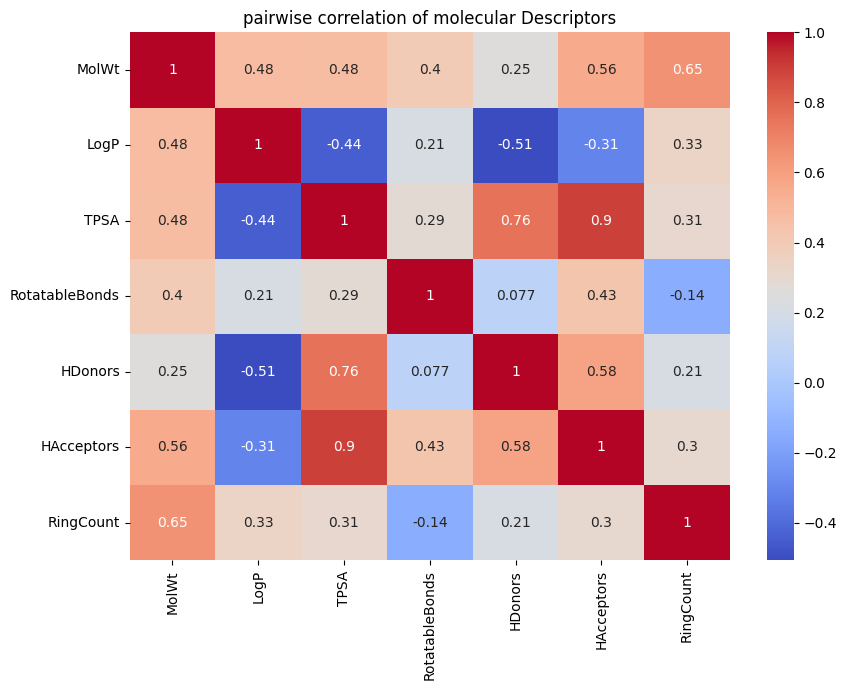

In [10]:
# TODO: Create a correlation heatmap of the descriptor_df
# Use sns.heatmap with annot=True, cmap='coolwarm', and a title
plt.figure(figsize=(9, 7))
sns.heatmap(descriptor_df.corr(),annot=True, cmap='coolwarm' )
plt.title("pairwise correlation of molecular Descriptors")
plt.tight_layout()
plt.show()

**Question 3.3:** Which two descriptors are most strongly correlated with each other? Why does this make chemical sense?

> **Your answer:** The strongest correlation is between HAcceptors and TPSA. This makes chemical sense because both descriptors are mainly determined by polar heteroatoms such as oxygen and nitrogen; molecules with more hydrogen-bond acceptors usually have a larger polar surface area.

### Descriptor vs. Solubility Scatter Plots

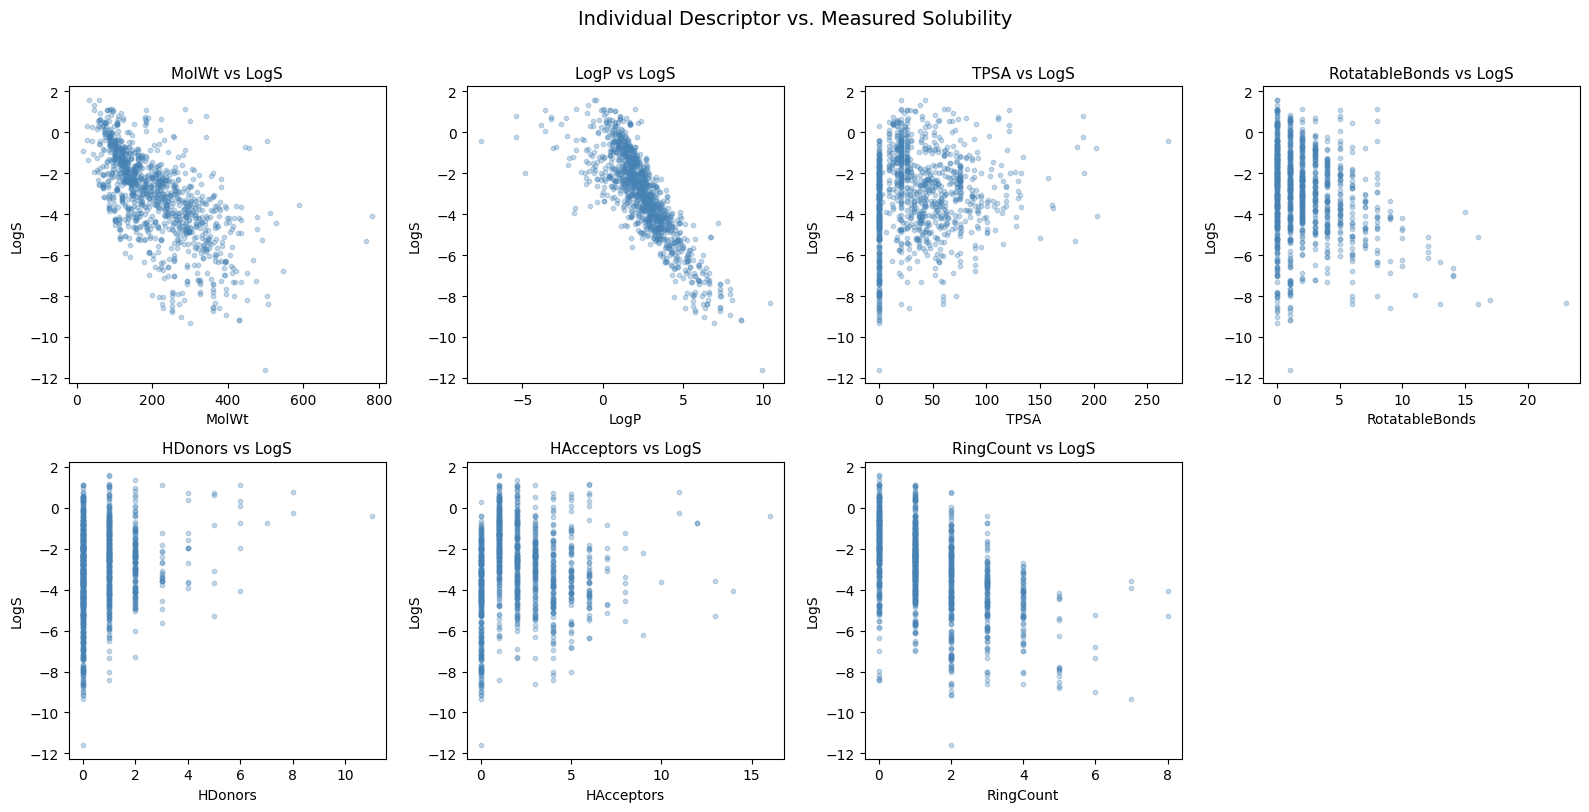

In [11]:
# Align descriptor_df index with df
valid_idx = descriptor_df.index
logS_aligned = df['logS'].iloc[valid_idx].values

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(descriptor_df.columns):
    axes[i].scatter(descriptor_df[col], logS_aligned, alpha=0.3, s=10, color='steelblue')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("LogS", fontsize=10)
    axes[i].set_title(f"{col} vs LogS", fontsize=11)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle("Individual Descriptor vs. Measured Solubility", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Part 4 — Morgan Fingerprints

Molecular descriptors capture *global* properties (size, polarity, etc.).  
Morgan fingerprints capture *local* structure — which chemical substructures are present.

### How Morgan fingerprints work:
1. For each atom, look at the chemical environment within `radius` bonds
2. Hash each unique environment into a bit position
3. The result is a binary vector of length `n_bits`

The most common variant is **ECFP4** (radius=2, which captures up to 4-bond environments).

### Task 4.1 — Write the fingerprint generation function

In [12]:
def generate_fingerprint(smiles: str, radius: int = 2, n_bits: int = 2048):
    """
    Generate a Morgan (ECFP4) fingerprint as a binary numpy array.

    Parameters
    ----------
    smiles  : SMILES string
    radius  : Neighborhood radius (2 = ECFP4)
    n_bits  : Length of the binary vector

    Returns
    -------
    np.ndarray of 0s and 1s, or None for invalid SMILES.
    """
    # TODO: Convert SMILES to mol object
    mol = Chem.MolFromSmiles(smiles)

    # TODO: Return None if invalid
    if mol is None:
        return None

    # TODO: Generate the Morgan fingerprint using AllChem.GetMorganFingerprintAsBitVect()
    # Arguments: mol, radius, nBits=n_bits
    fp = AllChem.GetMorganFingerprintAsBitVect(mol,radius, nBits=n_bits)

    # TODO: Convert fp to a numpy array and return it
    return np.array(fp)

### Task 4.2 — Generate fingerprints for all valid molecules

In [13]:
# TODO: Apply generate_fingerprint to all SMILES in df at valid_idx positions
# Collect results into a list, then build a DataFrame named `fingerprint_df`
fingerprints = [generate_fingerprint(smi) for smi in df['smiles'].iloc[valid_idx]]

fingerprint_df = pd.DataFrame(
    fingerprints,
    index=valid_idx,
    columns=[f"FP_{i}" for i in range(2048)]
)

print(f"Fingerprint matrix shape: {fingerprint_df.shape}")

# TODO: What fraction of bits are set on average? (Hint: .values.mean())
bit_density = fingerprint_df.values.mean()
print(f"Mean bit density: {bit_density:.4f}")

[20:30:15] DEPRECATION WARNING: please use MorganGenerator
[20:30:15] DEPRECATION WARNING: please use MorganGenerator
[20:30:15] DEPRECATION WARNING: please use MorganGenerator
[20:30:15] DEPRECATION WARNING: please use MorganGenerator
[20:30:15] DEPRECATION WARNING: please use MorganGenerator
[20:30:15] DEPRECATION WARNING: please use MorganGenerator
[20:30:15] DEPRECATION WARNING: please use MorganGenerator
[20:30:15] DEPRECATION WARNING: please use MorganGenerator
[20:30:15] DEPRECATION WARNING: please use MorganGenerator
[20:30:15] DEPRECATION WARNING: please use MorganGenerator
[20:30:15] DEPRECATION WARNING: please use MorganGenerator
[20:30:15] DEPRECATION WARNING: please use MorganGenerator
[20:30:15] DEPRECATION WARNING: please use MorganGenerator
[20:30:15] DEPRECATION WARNING: please use MorganGenerator
[20:30:15] DEPRECATION WARNING: please use MorganGenerator
[20:30:15] DEPRECATION WARNING: please use MorganGenerator
[20:30:15] DEPRECATION WARNING: please use MorganGenerat

Fingerprint matrix shape: (1128, 2048)
Mean bit density: 0.0105


In [14]:
print(fingerprint_df)

      FP_0  FP_1  FP_2  FP_3  FP_4  FP_5  FP_6  FP_7  FP_8  FP_9  ...  \
0        0     1     0     0     0     0     0     0     0     0  ...   
1        0     0     0     0     0     0     0     0     0     0  ...   
2        0     0     0     0     0     0     0     0     0     0  ...   
3        0     0     0     0     0     0     0     0     0     0  ...   
4        0     0     0     0     0     0     0     0     0     0  ...   
...    ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   
1123     0     1     0     0     0     0     0     0     0     0  ...   
1124     0     0     0     0     0     0     0     0     0     0  ...   
1125     0     0     0     0     0     0     0     0     0     0  ...   
1126     0     1     0     0     0     0     0     0     0     0  ...   
1127     0     0     0     0     0     0     0     0     0     0  ...   

      FP_2038  FP_2039  FP_2040  FP_2041  FP_2042  FP_2043  FP_2044  FP_2045  \
0           0        0        0        0   

**Question 4.2:** Morgan fingerprints are sparse (very few bits are set to 1). Why is this expected? What would it mean if a fingerprint were dense (most bits set)?

> **Your answer:** Morgan fingerprints are expected to be sparse because each molecule contains only a small subset of all possible chemical substructures, so most bits remain zero. If a fingerprint were dense, it could indicate a very large or complex molecule, too short a fingerprint length, or many bit collisions, which may reduce the ability to distinguish molecules.

---

## Part 5 — Build the Feature Matrix

Now we combine descriptors and fingerprints into one unified feature matrix `X`.

### Task 5.1 — Concatenate features

In [15]:
# TODO: Concatenate descriptor_df and fingerprint_df side by side (axis=1)
# Reset the index of each first so they align properly
X = pd.concat(
    [descriptor_df.reset_index(drop=True), fingerprint_df.reset_index(drop=True)],
    axis=1
)

# RDKit descriptor names and integer column names need to be strings for sklearn
X.columns = X.columns.astype(str)

# TODO: Build y from df['logS'] at valid_idx, and reset the index
y = df['logS'].iloc[valid_idx].reset_index(drop=True)

print(f"Feature matrix X: {X.shape}")
print(f"Target vector y:  {y.shape}")
print(f"\nFeature breakdown:")
print(f"  Physicochemical descriptors: 7")
print(f"  Morgan fingerprint bits:     2048")
print(f"  Total features:              {X.shape[1]}")

Feature matrix X: (1128, 2055)
Target vector y:  (1128,)

Feature breakdown:
  Physicochemical descriptors: 7
  Morgan fingerprint bits:     2048
  Total features:              2055


### Task 5.2 — Standardize the features

In [16]:
# TODO: Create a StandardScaler and fit_transform X_scaled from X
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled with zero mean and unit variance.")
print(f"Scaled matrix shape: {X_scaled.shape}")

Features scaled with zero mean and unit variance.
Scaled matrix shape: (1128, 2055)


> **Note:** Random Forest does not require scaling, but we scale here because PCA in the next section *does* require it. Scaling ensures that the 7 descriptor features (with large numeric ranges) don't dominate the 2048 fingerprint bits (which are just 0/1).

---

## Part 6 — PCA Visualization

PCA (Principal Component Analysis) compresses the 2055-dimensional feature space into 2 dimensions so we can visualize it.

### Task 6.1 — Fit PCA and print explained variance

In [17]:
# TODO: Create a PCA object with n_components=2 and random_state=42
pca = PCA(n_components=2, random_state=42)

# TODO: Fit and transform X_scaled, store result as X_pca
X_pca = pca.fit_transform(X_scaled)

# TODO: Print the explained variance ratio for PC1 and PC2 (as percentages)
explained = pca.explained_variance_ratio_ * 100
print(f"PC1: {explained[0]:.1f}% of variance explained")
print(f"PC2: {explained[1]:.1f}% of variance explained")
print(f"Total: {sum(explained):.1f}%")

PC1: 1.4% of variance explained
PC2: 0.9% of variance explained
Total: 2.3%


### Task 6.2 — Scatter plot colored by solubility

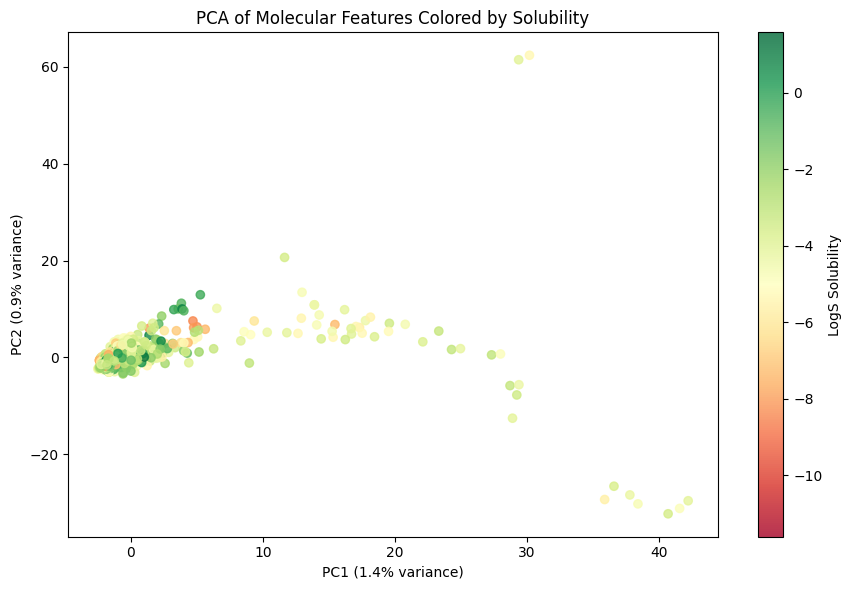

In [18]:
pca_df = pd.DataFrame({
    "PC1":        X_pca[:, 0],
    "PC2":        X_pca[:, 1],
    "Solubility": y.values
})

# TODO: Create a scatter plot of PC1 vs PC2
# Color the points by Solubility using a diverging colormap (e.g., 'RdYlGn')
# Add a colorbar, axis labels with % variance, and a title

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Solubility"],
    cmap="RdYlGn",
    alpha=0.8
)

plt.colorbar(scatter, label="LogS Solubility")

plt.xlabel(f"PC1 ({explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]:.1f}% variance)")
plt.title("PCA of Molecular Features Colored by Solubility")

plt.tight_layout()
plt.show()

**Question 6.2:** Does PCA reveal distinct clusters of molecules, or is the distribution continuous? What does this tell you about the nature of the solubility prediction problem?

> **Your answer:** The PCA plot does not show clearly separated clusters; instead, the molecules form a mostly continuous distribution with a few outliers. This suggests that solubility prediction is a continuous regression problem rather than a simple classification task. Solubility changes gradually with molecular features, so the model must learn continuous structure-property relationships rather than separating molecules into distinct groups.

---

## Part 7 — Train/Test Split

In [21]:
# TODO: Split X_scaled and y into training (80%) and test (20%) sets
# Use random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print(f"Training set:  {X_train.shape[0]} molecules ({100*X_train.shape[0]/len(y):.0f}%)")
print(f"Test set:      {X_test.shape[0]} molecules ({100*X_test.shape[0]/len(y):.0f}%)")

Training set:  902 molecules (80%)
Test set:      226 molecules (20%)


---

## Part 8 — Train the Random Forest Regressor

A **Random Forest** builds many decision trees on random subsets of the data and features,  
then averages their predictions. This reduces overfitting and gives robust estimates.

### Task 8.1 — Train the model

In [22]:
# TODO: Create a RandomForestRegressor with:
#   n_estimators=300, max_depth=25, min_samples_split=4,
#   random_state=42, n_jobs=-1
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    min_samples_split=4,
    random_state=42,
    n_jobs=-1
)

# TODO: Fit the model on the training data
model.fit(X_train, y_train)

print("Training complete.")
print(f"Number of trees: {model.n_estimators}")
print(f"Max tree depth:  {model.max_depth}")

Training complete.
Number of trees: 300
Max tree depth:  25


---

## Part 9 — Evaluate the Model

### Task 9.1 — Generate predictions and compute metrics

In [24]:
# TODO: Use model.predict() to generate predictions on the test set
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual LogS":    y_test.values,
    "Predicted LogS": y_pred,
    "Residual":       y_test.values - y_pred
})

print("Sample predictions (first 10):")
results.head(10).round(3)

Sample predictions (first 10):


,Actual LogS,Predicted LogS,Residual
0,-2.540,-2.560,0.020
1,-2.253,-2.314,0.061
2,-2.484,-2.465,-0.019
3,-2.540,-2.560,0.020
4,-7.200,-7.057,-0.143
5,-1.190,-0.835,-0.355
6,-4.314,-4.011,-0.303
7,-2.190,-1.785,-0.405
8,-7.660,-8.315,0.655
9,-2.570,-2.834,0.264


### Metrics

In [25]:
# TODO: Compute RMSE, MAE, and R² using sklearn's metric functions
# For RMSE: compute MSE first, then take the square root
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=" * 35)
print("       MODEL PERFORMANCE")
print("=" * 35)
print(f"  RMSE : {rmse:.3f} log(mol/L)")
print(f"  MAE  : {mae:.3f} log(mol/L)")
print(f"  R²   : {r2:.3f}")
print("=" * 35)

if r2 > 0.85:
    print("\n✓ Excellent model — strong predictive power.")
elif r2 > 0.70:
    print("\n~ Good model — acceptable for early screening.")
else:
    print("\n✗ Model needs improvement — consider additional features or hyperparameter tuning.")

       MODEL PERFORMANCE
  RMSE : 0.796 log(mol/L)
  MAE  : 0.548 log(mol/L)
  R²   : 0.866

✓ Excellent model — strong predictive power.


> **Interpretation guide:**  
> - **R² = 1.0**: perfect predictions  
> - **R² > 0.85**: excellent  
> - **R² > 0.70**: good for early drug screening  
> - **R² < 0.50**: model needs improvement

### Task 9.2 — Cross-Validation### Cross-Validation (more robust evaluation)

In [27]:
# Cross-validation gives a more reliable estimate than a single train/test split.
# TODO: Run 5-fold cross-validation using cross_val_score
# Use scoring='r2' and a RandomForestRegressor with n_estimators=100
cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X_scaled, y,
    cv=5,
    scoring='r2'
)

print(f"5-Fold CV R² scores: {cv_scores.round(3)}")
print(f"Mean CV R²:  {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

5-Fold CV R² scores: [0.915 0.902 0.915 0.879 0.85 ]
Mean CV R²:  0.892 ± 0.025


**Question 9.2:** Compare your single test-set R² with the cross-validation R². Which one do you trust more, and why?

> **Your answer:** The single test-set R² was 0.866, while the 5-fold cross-validation mean R² was 0.892 ± 0.025. I would trust the cross-validation result more because it evaluates the model across multiple train/test splits rather than relying on one random split. The low standard deviation also suggests that the model performance is stable and not strongly dependent on a particular test set.

---

## Part 10 — Regression Visualization

### Task 10.1 — Actual vs Predicted plot and Residual plot

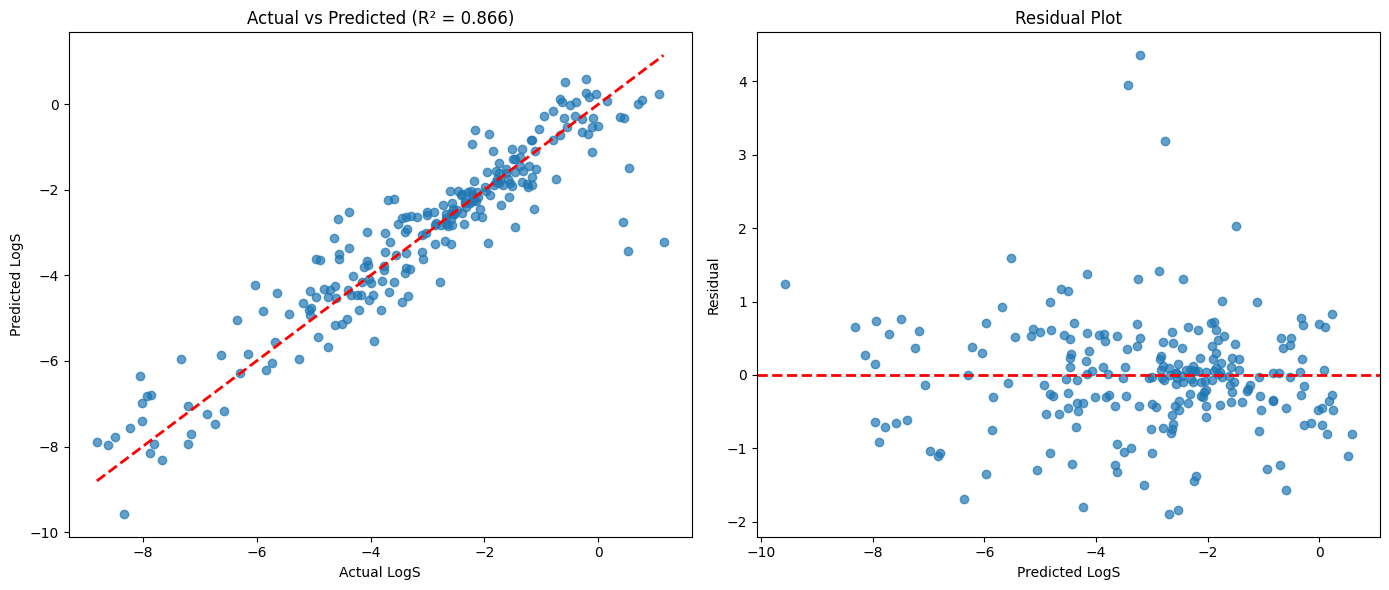

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel A: Actual vs Predicted ---
axes[0].scatter(y_test, y_pred, alpha=0.7)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel("Actual LogS")
axes[0].set_ylabel("Predicted LogS")
axes[0].set_title(f"Actual vs Predicted (R² = {r2:.3f})")

# --- Panel B: Residual Plot ---
residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.7)
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel("Predicted LogS")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

**Question 10.1:** Examine the residual plot. Are the residuals randomly scattered around zero? If you see a pattern, what could it indicate about the model?

> **Your answer:** The residuals are mostly scattered around zero, suggesting that the model does not show a strong systematic bias overall. However, there are a few clear outliers with large positive residuals, meaning the model underestimates the solubility for those molecules. If a stronger pattern were present, it could indicate that the model is missing important nonlinear relationships or specific chemical features.

---

## Part 11 — Feature Importance Analysis

Random Forest can rank features by how much they contribute to predictions.  
This is called **Mean Decrease in Impurity (MDI)** importance.

### Task 11.1 — Extract and display feature importances

In [29]:
# TODO: Get feature importances from model.feature_importances_
importance = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature":    X.columns.tolist(),
    "Importance": importance
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Top 15 most important features:")
importance_df.head(15)

Top 15 most important features:


,Feature,Importance
0,LogP,0.800746
1,MolWt,0.081181
2,TPSA,0.029256
3,HAcceptors,0.004781
4,RingCount,0.003629
5,RotatableBonds,0.003258
6,FP_807,0.002848
7,HDonors,0.002358
8,FP_1602,0.002022
9,FP_650,0.001997


### Task 11.2 — Bar plot of top 15 features

In [30]:
# Separate descriptor importance from fingerprint importance
desc_names = ["MolWt", "LogP", "TPSA", "RotatableBonds", "HDonors", "HAcceptors", "RingCount"]
desc_imp   = importance_df[importance_df["Feature"].isin(desc_names)]
fp_total   = importance_df[~importance_df["Feature"].isin(desc_names)]["Importance"].sum()

print("\nDescriptor contributions:")
for _, row in desc_imp.iterrows():
    print(f"  {row['Feature']:20s}: {row['Importance']:.4f}")
print(f"\n  {'All FP bits (total)':20s}: {fp_total:.4f}")


Descriptor contributions:
  LogP                : 0.8007
  MolWt               : 0.0812
  TPSA                : 0.0293
  HAcceptors          : 0.0048
  RingCount           : 0.0036
  RotatableBonds      : 0.0033
  HDonors             : 0.0024

  All FP bits (total) : 0.0748


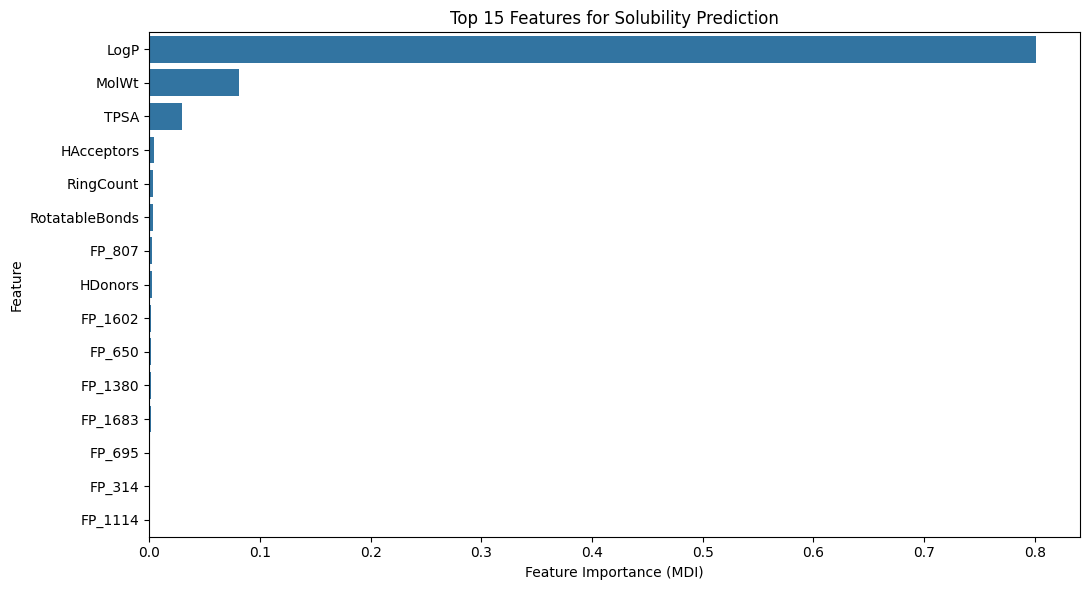

In [31]:
# TODO: Create a horizontal bar chart showing the top 15 features by importance
# (Hint: use plt.barh or sns.barplot with a horizontal orientation)
# Make sure features are sorted from most important (top) to least (bottom)
top15 = importance_df.head(15)

plt.figure(figsize=(11, 6))

# Horizontal bar chart
sns.barplot(
    x="Importance",
    y="Feature",
    data=top15,
    orient="h"
)

plt.xlabel("Feature Importance (MDI)")
plt.title("Top 15 Features for Solubility Prediction")
plt.tight_layout()
plt.show()

**Question 11.2:** Which physicochemical descriptor appears most important? Does this match your intuition about solubility from Part 3? Explain.

> **Your answer:** LogP.yes this matches my intuition from Part 3 because LogP represents molecular hydrophobicity/lipophilicity. Molecules with higher LogP are more hydrophobic and usually less soluble in water, while molecules with lower LogP tend to be more polar and more water-soluble. Therefore, it makes chemical sense that LogP is highly important for predicting LogS.

---

## Part 12 — Discussion Questions

Answer each question in 3–5 sentences. Use correct scientific terminology.

**Q1.** LogP is consistently one of the most predictive features for aqueous solubility. Explain the physical and chemical basis for this relationship.

> **Your answer:** LogP measures the partitioning of a molecule between a nonpolar solvent (like octanol) and water, reflecting its hydrophobicity. Molecules with higher LogP are more hydrophobic and interact less favorably with water, resulting in lower solubility. Conversely, molecules with lower LogP are more polar and form favorable interactions, including hydrogen bonds, with water, leading to higher solubility. Therefore, LogP directly captures a key thermodynamic determinant of aqueous solubility

---

**Q2.** We combined two types of features: physicochemical descriptors and Morgan fingerprints. What unique information does each type contribute? Would you expect the model to perform better or worse if you used only one type — and which one?

> **Your answer:** Physicochemical descriptors summarize global molecular properties such as size, polarity, and hydrogen-bonding potential, which are easily interpretable. Morgan fingerprints encode detailed substructural patterns and local chemical environments that may not be captured by global descriptors. Using only descriptors might miss subtle structural effects, while using only fingerprints might ignore global physicochemical trends. Combining both types allows the model to capture complementary information, leading to better predictive performance

---

**Q3.** This assignment used the ESOL dataset, which contains mostly drug-like organic molecules. If you tried to apply this model to predict the solubility of ionic compounds (like salts) or polymers, what problems might arise?

> **Your answer:** The model is trained on neutral, drug-like organic molecules, so it may not generalize to ionic compounds or polymers. Ionic compounds dissolve via ion dissociation, which is governed by different thermodynamics than predicted by LogP or the fingerprints used here. Polymers often have repeating units and very different sizes and conformations, which are not represented in the training data. Therefore, predictions for these molecules would likely be inaccurate due to extrapolation beyond the domain of the ESOL dataset



---

## Submission Checklist

Before submitting, confirm:

- [ ] All `___` placeholders have been replaced with working code
- [ ] All cells run without errors from top to bottom (Kernel → Restart & Run All)
- [ ] All plots are visible and properly labeled (axes, titles)
- [ ] All written questions have been answered in your own words
- [ ] Your name and student ID are filled in at the top of this notebook

---
